# Tensor Report Card

Not all bloq examples support tensor simulation. This report card automatically determines which bloq examples should be tensor simulable.

 - State vector simulation uses $2^n$ numbers to simulate a quantum state. The tensor protocol uses quimb to try to find more efficient contraction orderings. Quimb reports the contraction width, which is the minimum size of any intermediate tensor encountered in the contraciton. The simulation uses $2^w$ numbers, where $w$ is the width. We consider a width under 25 qubits as simulable.
 - Qualtran requires "flattening" out the bloq to turn it into an efficient tensor network. This may take too much time itself for large algorithms with many levels of abstraction. If the process of turning a bloq into a quimb tensor network and finding a contraction ordering takes longer than 8 seconds, we don't consider the bloq simulable.
 - The flattened structure needs to have explicit tensors. For bloqs with symbolic parameters, we either can't decompose & flatten them, or the tensors would be symbolic, which we don't support.

In [1]:
from qualtran_dev_tools.bloq_finder import get_bloq_examples
from qualtran_dev_tools.tensor_report_card import report_on_tensors, ExecuteWithTimeout

In [2]:
bes = get_bloq_examples()

# Imports to exclude certain bloqs, see following comment
from qualtran.bloqs.multiplexers.apply_gate_to_lth_target import ApplyGateToLthQubit

In [3]:
exec = ExecuteWithTimeout(timeout=10., max_workers=4)
for i, be in enumerate(bes):

    if be.bloq_cls == ApplyGateToLthQubit:
        # This bloq uses a lambda function as one of its attributes, which
        # can't be pickled and used with multiprocessing.
        continue
    
    exec.submit(report_on_tensors, 
                kwargs=dict(name=be.name, cls_name=be.qualified_cls_name, bloq=be.make()),
                task_name=f'{be.qualified_cls_name}.{be.name}')

records = []
while exec.work_to_be_done:
    kwargs, record = exec.next_result()
    #print(kwargs['name'], end=' ', flush=True)
    print('\r', f'{exec.work_to_be_done:5d} remaining', end='', flush=True)
    
    if record is None:
        records.append({
            'name': kwargs['name'],
            'cls': kwargs['cls_name'],
            'err': 'Timeout',
        })
    else:
        records.append(record)

import pandas as pd
df = pd.DataFrame(records)

   128 remaining

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/mpharrigan/qutran/py311-cf/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mpharrigan/qutran/py311-cf/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'FieldArray_2_3_2_11' on <module 'galois._fields._factory' from '/Users/mpharrigan/qutran/py311-cf/lib/python3.11/site-packages/galois/_fields/_factory.py'>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/mpharrigan/qutran/py311-cf/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mpharrigan/qutran/py311-cf/lib/python3.11/multiprocessing/spawn.p

     0 remaining

## Number of bloq examples considered

In [4]:
print(len(df))

363


In [5]:
# Gate count proxy

In [6]:
df.head()

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
0,add_diff_size_regs,qualtran.bloqs.arithmetic.Add,117,0.000066,0.068463,87.0,0.003365,40.0,0.005659,NaN
1,add_k,qualtran.bloqs.arithmetic.AddK,10*n - 11,0.015530,0.050107,1.0,NaN,NaN,NaN,AddK does not support tensor simulation.
2,add_k_small,qualtran.bloqs.arithmetic.AddK,23,0.000155,0.007025,33.0,0.001419,9.0,0.001631,NaN
3,add_k_large,qualtran.bloqs.arithmetic.AddK,623,0.000170,0.169929,633.0,0.128436,128.0,0.075257,NaN
4,add_oop_small,qualtran.bloqs.arithmetic.OutOfPlaceAdder,24,0.000069,0.008231,30.0,0.001283,21.0,0.001515,NaN


In [7]:
df2 = df.copy()
df2['gates'] = pd.to_numeric(df2['gates'], errors='coerce')

In [8]:
import matplotlib.pyplot as plt
import numpy as np

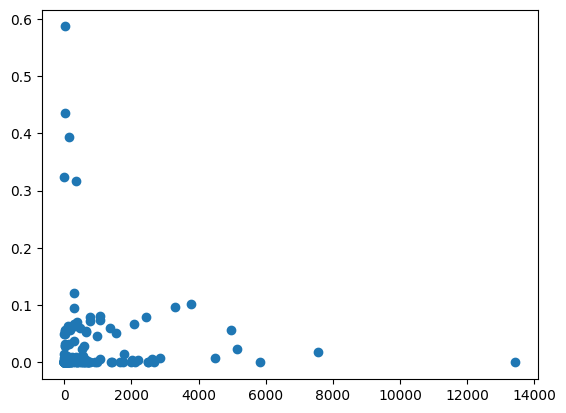

In [9]:
plt.scatter(df2['gates'], df2['gc_dur'])

Text(0, 0.5, 'Flatten duration')

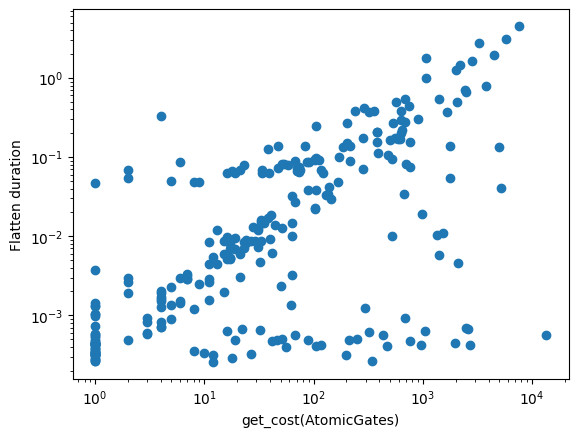

In [10]:
plt.scatter(df2['gates'], df2['flat_dur'])
#plt.xlim((0, 1_000))
#plt.ylim((0, 0.5))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('get_cost(AtomicGates)')
plt.ylabel('Flatten duration')

Text(0, 0.5, 'Bloqs in flat circuit')

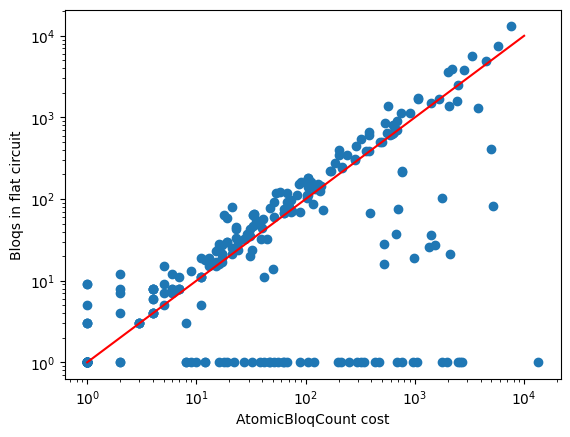

In [11]:
plt.scatter(df2['gates'], df2['flat_gc'])
xx = np.logspace(0, 4, base=10)
plt.plot(xx, xx, color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('AtomicBloqCount cost')
plt.ylabel('Bloqs in flat circuit')

Text(0, 0.5, 'Flatten duration / s')

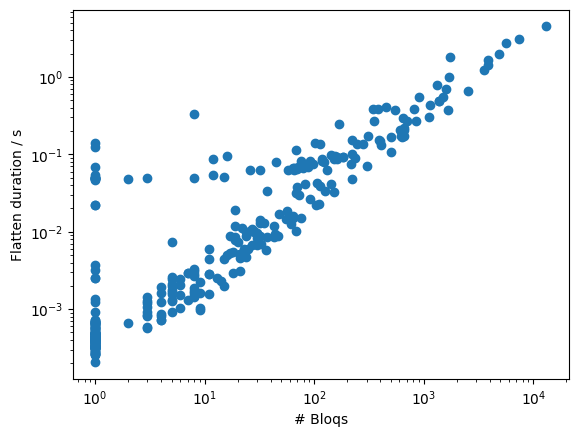

In [12]:
plt.scatter(df2['flat_gc'], df2['flat_dur'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('# Bloqs')
plt.ylabel('Flatten duration / s')

In [13]:
df2[(df2['flat_gc']<2)&(df2['flat_dur']>1e-2)]

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
1,add_k,qualtran.bloqs.arithmetic.AddK,NaN,0.015530,0.050107,1.0,NaN,NaN,NaN,AddK does not support tensor simulation.
5,add_oop_symb,qualtran.bloqs.arithmetic.OutOfPlaceAdder,NaN,0.015627,0.051284,1.0,NaN,NaN,NaN,OutOfPlaceAdder does not support tensor simula...
9,add_symb,qualtran.bloqs.arithmetic.Add,NaN,0.014844,0.049714,1.0,NaN,NaN,NaN,Add does not support tensor simulation.
23,leq_symb,qualtran.bloqs.arithmetic.LessThanEqual,NaN,0.016599,0.049090,1.0,NaN,NaN,NaN,LessThanEqual does not support tensor simulation.
28,lt_k_symb,qualtran.bloqs.arithmetic.LessThanConstant,NaN,0.015590,0.049051,1.0,NaN,NaN,NaN,LessThanConstant does not support tensor simul...
142,tensor_product_block_encoding_symb,qualtran.bloqs.block_encoding.TensorProduct,2.0,0.000229,0.069482,1.0,NaN,NaN,NaN,B[T⊗H] does not support tensor simulation.
163,prep_mu_proj,qualtran.bloqs.chemistry.pbc.first_quantizatio...,9.0,0.000042,0.048279,1.0,NaN,NaN,NaN,PrepareMuUnaryEncodedOneHotWithProj does not s...
165,prep_power_two_proj,qualtran.bloqs.chemistry.pbc.first_quantizatio...,8.0,0.000038,0.048098,1.0,NaN,NaN,NaN,PreparePowerTwoStateWithProj does not support ...
166,prep_t_proj,qualtran.bloqs.chemistry.pbc.first_quantizatio...,47.0,0.000051,0.139095,1.0,NaN,NaN,NaN,PrepareTFirstQuantizationWithProj does not sup...
169,sel_t_proj,qualtran.bloqs.chemistry.pbc.first_quantizatio...,38.0,0.000102,0.124851,1.0,NaN,NaN,NaN,SelectTFirstQuantizationWithProj does not supp...


In [14]:
df[df['gates'].isna()]

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
39,cadd_large,qualtran.bloqs.arithmetic.CAdd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
198,potential_energy,qualtran.bloqs.chemistry.trotter.grid_ham.Pote...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
208,ec_add_small,qualtran.bloqs.cryptography.ecc.ECAdd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
209,ec_window_add_r_small,qualtran.bloqs.cryptography.ecc.ECWindowAddR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
211,modexp,qualtran.bloqs.cryptography.rsa.ModExp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
213,modexp_small,qualtran.bloqs.cryptography.rsa.ModExp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
219,rsa_pe_small,qualtran.bloqs.cryptography.rsa.RSAPhaseEstimate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
236,gf2_multiply_by_constant_modulu,qualtran.bloqs.gf_arithmetic.GF2MultiplyByCons...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
237,gf2_poly_multiply_by_constant_modulu,qualtran.bloqs.gf_arithmetic.GF2MultiplyByCons...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout
244,hubbard_time_evolution_by_gqsp,qualtran.bloqs.hamiltonian_simulation.Hamilton...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Timeout


In [15]:
from qualtran.bloqs.cryptography.ecc.ec_add import _ec_add_small
from qualtran.resource_counting import AtomicBloqCount, get_cost_value

In [16]:
get_cost_value(_ec_add_small.make(), AtomicBloqCount())

24708

In [17]:
import multiprocessing
be = _ec_add_small
recv, send = multiprocessing.Pipe(duplex=False)
p = multiprocessing.Process(target=report_on_tensors, kwargs=dict(name=be.name, cls_name=be.qualified_cls_name, bloq=be.make(), cxn=send))
print("made p", flush=True)
p.start()
print("started", flush=True)
p.join()
print("!", flush=True)

made p
started
!


## Number of bloq examples successfully flattened

In [18]:
print(len(df[df['flat_dur'] > 0]))

334


In [19]:
print(len(df[~(df['flat_dur'] > 0)]))

29


In [22]:
df[(df['gc_dur']>0)&(df['flat_dur'].isna())]

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
38,has_duplicates_symb_len,qualtran.bloqs.arithmetic.lists.HasDuplicates,2*l + 2*(l - 1)*(9*n + 6) - 2,0.072184,NaN,NaN,NaN,NaN,NaN,"cannot add register with symbolic shape (l,)"
42,symm_diff_equal_size_symb,qualtran.bloqs.arithmetic.lists.SymmetricDiffe...,2*c*k*(25*ceiling(log2(n)) + 14)*(ceiling(log2...,0.079935,NaN,NaN,NaN,NaN,NaN,"cannot add register with symbolic shape (c*k,)"
43,symm_diff_symb,qualtran.bloqs.arithmetic.lists.SymmetricDiffe...,2*c*k*(25*ceiling(log2(n)) + 14)*(ceiling(log2...,0.080458,NaN,NaN,NaN,NaN,NaN,"cannot add register with symbolic shape (c*k,)"
75,sub_symp_decomposition,qualtran._infra.CompositeBloq,11*n - 7,0.100010,NaN,NaN,NaN,NaN,NaN,LeftDangle.a is not an available Soquet for `C...
231,gf2_inverse_symbolic,qualtran.bloqs.gf_arithmetic.GF2Inverse,m*(ceiling(log2(m)) + 2) + (m**2 + ceiling(m**...,0.025881,NaN,NaN,NaN,NaN,NaN,cannot add register with symbolic shape (3*cei...
245,multi_and_symb,qualtran.bloqs.mcmt.MultiAnd,n - 1,0.014046,NaN,NaN,NaN,NaN,NaN,"cannot add register with symbolic shape (n,)"
254,ctrl_on_symbolic_n_ctrls,qualtran.bloqs.mcmt.CtrlSpecAnd,n - 1,0.016409,NaN,NaN,NaN,NaN,NaN,"cannot add register with symbolic shape (n,)"
256,ccpauli_symb,qualtran.bloqs.mcmt.MultiControlX,2*n - 1,0.015017,NaN,NaN,NaN,NaN,NaN,"cannot add register with symbolic shape (n,)"
285,guiding_state_symb,qualtran.bloqs.optimization.k_xor_sat.GuidingS...,24*k**2*(25*ceiling(log2(n)) + 14) + 12*k**2*c...,0.105332,NaN,NaN,NaN,NaN,NaN,"Register(name='xs', dtype=QUInt(bitsize=ceilin..."
292,lp_resource_state_symbolic,qualtran.bloqs.phase_estimation.LPResourceState,17*n + 24,0.031048,NaN,NaN,NaN,NaN,NaN,loop of ufunc does not support argument 0 of t...


## Number of bloq examples with tensors

In [23]:
print(len(df[df['width'] > 0]))

187


In [26]:
# You can use this query to see all the new failures, but
# a lot of them don't decompose even once.
# df[(df['flat_dur']>0)&(df['width'].isna())]

df[(df['flat_gc']>1)&(df['width'].isna())]

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
31,ctrl_add_or_sub_signed_symb,qualtran.bloqs.arithmetic.ControlledAddOrSubtract,10*n - 9,0.062816,0.002485,5.0,NaN,NaN,NaN,'Symbol' object cannot be interpreted as an in...
41,has_duplicates_symb,qualtran.bloqs.arithmetic.lists.HasDuplicates,54*n + 42,0.073566,0.011067,22.0,NaN,NaN,NaN,LinearDepthHalfLessThan does not support tenso...
54,negate_symb,qualtran.bloqs.arithmetic.Negate,11*n - 11,0.015926,0.047682,2.0,NaN,NaN,NaN,XGate⨂n does not support tensor simulation.
58,permutation_cycle_symb_N,qualtran.bloqs.arithmetic.PermutationCycle,11*ceiling(log2(n)) - 2,0.063307,0.001633,9.0,NaN,NaN,NaN,EqualsAConstant does not support tensor simula...
60,permutation_symb_with_cycles,qualtran.bloqs.arithmetic.Permutation,(2*ceiling(log2(N)) - 1)*(d[0] + 1) + (2*ceili...,0.065007,0.000873,4.0,NaN,NaN,NaN,PermutationCycle does not support tensor simul...
62,sparse_permutation_with_symbolic_N,qualtran.bloqs.arithmetic.Permutation,22*ceiling(log2(N)) - 4,0.063531,0.002918,18.0,NaN,NaN,NaN,EqualsAConstant does not support tensor simula...
63,bitonic_sort_symb,qualtran.bloqs.arithmetic.BitonicSort,150*n + 84,0.065706,0.009938,24.0,NaN,NaN,NaN,LessThanEqual does not support tensor simulation.
67,comparator_symb,qualtran.bloqs.arithmetic.Comparator,25*n + 14,0.130794,0.001598,4.0,NaN,NaN,NaN,LessThanEqual does not support tensor simulation.
72,sub_from_symb,qualtran.bloqs.arithmetic.SubtractFrom,10*n - 11,0.016252,0.048979,3.0,NaN,NaN,NaN,XGate⨂n does not support tensor simulation.
76,sub_symb,qualtran.bloqs.arithmetic.Subtract,11*n - 11,0.015886,0.050108,8.0,NaN,NaN,NaN,'Symbol' object cannot be interpreted as an in...


## Bloqs that are tensor simulable

In [27]:
print(len(df[df['width'] <= 25]))
df[df['width'] <= 25]

138


,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
2,add_k_small,qualtran.bloqs.arithmetic.AddK,23,0.000155,0.007025,33.0,0.001419,9.0,0.001631,NaN
4,add_oop_small,qualtran.bloqs.arithmetic.OutOfPlaceAdder,24,0.000069,0.008231,30.0,0.001283,21.0,0.001515,NaN
8,add_small,qualtran.bloqs.arithmetic.Add,21,0.000079,0.005974,25.0,0.001116,16.0,0.001284,NaN
11,bitwise_not,qualtran.bloqs.arithmetic.BitwiseNot,4,0.000215,0.001507,6.0,0.000445,8.0,0.000350,NaN
12,xor,qualtran.bloqs.arithmetic.Xor,4,0.000056,0.001698,8.0,0.000733,16.0,0.000532,NaN
...,...,...,...,...,...,...,...,...,...,...
347,sparse_state_prep_via_rotations,qualtran.bloqs.state_preparation.SparseStatePr...,240,0.009570,0.386949,344.0,0.019300,12.0,0.088060,NaN
351,state_prep_alias,qualtran.bloqs.state_preparation.StatePreparat...,91,0.004815,0.086633,161.0,0.005774,22.0,0.006947,NaN
353,state_prep_via_rotation,qualtran.bloqs.state_preparation.StatePreparat...,54,0.006815,0.082717,118.0,0.009317,10.0,0.005602,NaN
356,approx_cswap_small,qualtran.bloqs.swap_network.CSwapApprox,103,0.000130,0.022790,111.0,0.003107,18.0,0.003408,NaN


## Bloqs whose tensor network is too big

In [28]:
df[df['width'] > 25].sort_values(by='width')

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
22,leq,qualtran.bloqs.arithmetic.LessThanEqual,111,0.000242,0.092198,161.0,0.005316,2.600000e+01,0.007460,NaN
40,has_duplicates,qualtran.bloqs.arithmetic.lists.HasDuplicates,204,0.000922,0.149143,400.0,0.014385,2.600000e+01,0.018536,NaN
175,cplx_givens,qualtran.bloqs.chemistry.quad_fermion.ComplexG...,105,0.001136,0.096807,141.0,0.005575,2.800000e+01,0.008415,NaN
359,multiplexed_cswap,qualtran.bloqs.swap_network.MultiplexedCSwap,23,0.002931,0.008447,43.0,0.001734,3.000000e+01,0.001961,NaN
316,prepare_identity,qualtran.bloqs.reflections.PrepareIdentity,3,0.000239,0.000814,3.0,0.000332,3.000000e+01,0.000399,NaN
283,black_box_select,qualtran.bloqs.multiplexers.BlackBoxSelect,129,0.032802,0.032731,153.0,0.006778,3.200000e+01,0.009815,NaN
290,kaiser_window_state_small,qualtran.bloqs.phase_estimation.KaiserWindowState,344,0.316197,0.000261,1.0,0.000177,3.200000e+01,0.000087,NaN
243,and_bloq,qualtran.bloqs.mcmt.And,1,0.000029,0.000489,1.0,0.000210,3.200000e+01,0.000088,NaN
349,sparse_state_prep_alias,qualtran.bloqs.state_preparation.SparseStatePr...,104,0.004979,0.092586,182.0,0.006672,3.400000e+01,0.009453,NaN
348,sparse_state_prep_alias_from_list,qualtran.bloqs.state_preparation.SparseStatePr...,104,0.005286,0.093628,182.0,0.007615,3.400000e+01,0.010428,NaN


## Bloqs without tensors

Due to errors encountered in flattening or if the bloq's callees don't support tensor simulation.

In [29]:
df[df['width'].isna()]

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
1,add_k,qualtran.bloqs.arithmetic.AddK,10*n - 11,0.015530,0.050107,1.0,NaN,NaN,NaN,AddK does not support tensor simulation.
5,add_oop_symb,qualtran.bloqs.arithmetic.OutOfPlaceAdder,6*n,0.015627,0.051284,1.0,NaN,NaN,NaN,OutOfPlaceAdder does not support tensor simula...
9,add_symb,qualtran.bloqs.arithmetic.Add,8*n - 11,0.014844,0.049714,1.0,NaN,NaN,NaN,Add does not support tensor simulation.
10,bitwise_not_symb,qualtran.bloqs.arithmetic.BitwiseNot,n,0.000313,0.000683,1.0,NaN,NaN,NaN,XGate⨂n does not support tensor simulation.
13,xor_symb,qualtran.bloqs.arithmetic.Xor,n,0.000085,0.000380,1.0,NaN,NaN,NaN,Xor does not support tensor simulation.
...,...,...,...,...,...,...,...,...,...,...
350,sparse_state_prep_alias_symb,qualtran.bloqs.state_preparation.SparseStatePr...,d*ceiling(log2(1/(L*\epsilon)))*ceiling(log2(f...,0.007888,0.002143,5.0,NaN,NaN,NaN,PrepareUniformSuperposition does not support t...
352,state_prep_alias_symb,qualtran.bloqs.state_preparation.StatePreparat...,L*ceiling(log2(\lambda/(L*\epsilon)))*ceiling(...,0.067389,0.001977,5.0,NaN,NaN,NaN,PrepareUniformSuperposition does not support t...
354,state_prep_via_rotation_symb_phasegrad,qualtran.bloqs.state_preparation.StatePreparat...,34*b_\text{grad} + 60,0.070134,0.000612,1.0,NaN,NaN,NaN,StatePreparationViaRotations does not support ...
355,state_prep_via_rotation_symb,qualtran.bloqs.state_preparation.StatePreparat...,4*L*\text{phase_bitsize} + 8*L + 2*\text{phase...,0.072730,0.000503,1.0,NaN,NaN,NaN,StatePreparationViaRotations does not support ...


## Slowest to flatten

Within the overall timeout

In [30]:
df.sort_values(by='flat_dur', ascending=False).head()

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
300,qubitization_qpe_ising,qualtran.bloqs.phase_estimation.QubitizationQPE,7558,0.018947,4.507021,13060.0,0.565396,21.0,1.180336,NaN
280,modmul,qualtran.bloqs.mod_arithmetic.CModMulK,5816,0.001344,3.109528,7474.0,0.439295,34.0,1.246486,NaN
318,walk_op_chem_sparse,qualtran.bloqs.qubitization.QubitizationWalkOp...,3301,0.096206,2.732827,5591.0,NaN,NaN,NaN,QROAMCleanAdjoint does not support tensor simu...
272,dirtyoutofplacemontgomerymodmul_medium,qualtran.bloqs.mod_arithmetic.DirtyOutOfPlaceM...,4475,0.007426,1.968750,4878.0,NaN,NaN,NaN,QROAMCleanAdjoint does not support tensor simu...
241,random_walk_evolution_by_gqsp,qualtran.bloqs.hamiltonian_simulation.Hamilton...,1066,0.081029,1.785643,1746.0,0.121231,14.0,0.128583,NaN


## Flattening is the rate-limiting step.

For bloqs that have been successfully flattened, the maximum tensor-network-construction and tensor-contraction-ordering durations are less than 0.5s. Note: the contraction finding code uses the fast, naive approach. One can choose more expensive approaches where the contraciton-ordering-finding is more expensive.

In [31]:
# Slowest tn_dur
df.sort_values(by='tn_dur', ascending=False).head()

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
300,qubitization_qpe_ising,qualtran.bloqs.phase_estimation.QubitizationQPE,7558,0.018947,4.507021,13060.0,0.565396,21.0,1.180336,NaN
280,modmul,qualtran.bloqs.mod_arithmetic.CModMulK,5816,0.001344,3.109528,7474.0,0.439295,34.0,1.246486,NaN
65,bitonic_sort,qualtran.bloqs.arithmetic.BitonicSort,2208,0.003787,1.439463,3888.0,0.379997,88.0,0.393369,NaN
124,scaled_chebyshev_poly_even,qualtran.bloqs.block_encoding.ScaledChebyshevP...,1077,0.073837,1.005532,1703.0,0.233751,46.0,0.243025,NaN
73,sub_large,qualtran.bloqs.arithmetic.Subtract,693,0.000148,0.273534,707.0,0.165871,256.0,0.094940,NaN


In [32]:
# Slowest width_dur
df.sort_values(by='width_dur', ascending=False).head()

,name,cls,gates,gc_dur,flat_dur,flat_gc,tn_dur,width,width_dur,err
280,modmul,qualtran.bloqs.mod_arithmetic.CModMulK,5816,0.001344,3.109528,7474.0,0.439295,34.0,1.246486,NaN
300,qubitization_qpe_ising,qualtran.bloqs.phase_estimation.QubitizationQPE,7558,0.018947,4.507021,13060.0,0.565396,21.0,1.180336,NaN
64,bitonic_merge,qualtran.bloqs.arithmetic.BitonicMerge,2004,0.003726,1.241417,3564.0,0.118238,124.0,0.598008,NaN
65,bitonic_sort,qualtran.bloqs.arithmetic.BitonicSort,2208,0.003787,1.439463,3888.0,0.379997,88.0,0.393369,NaN
124,scaled_chebyshev_poly_even,qualtran.bloqs.block_encoding.ScaledChebyshevP...,1077,0.073837,1.005532,1703.0,0.233751,46.0,0.243025,NaN
